# 📘 Project 21 — Explainable EHR Graph Risk Prediction
**Team No.:** 2  **Team Members:** Nimisha Mohanty; BijayaLaxmi Swain; Amarjyoti Sahoo; Aditi Sahu

**Proposed Hybrid Model:** Clinical Temporal Transformer + Heterogeneous GAT

**Dataset / Source:** MIMIC-IV cleaned medical transcripts (small denormalized cohort)  
**Dataset Link:** https://www.kaggle.com/datasets/isaacritharson/mimic-iv-cleaned-medical-transcripts

**Task Type:** Multiclass classification — APR-DRG mortality-risk level prediction

### Multiclass target
The notebook uses the available `drg_mortality` APR-DRG risk-of-mortality field as an **ordered multiclass target**:
- Level 1 — Minor
- Level 2 — Moderate
- Level 3 — Major
- Level 4 — Extreme

At runtime the notebook detects which valid levels (1–4) are actually present. If at least three valid levels are available it trains a true multiclass model; when all four are present it trains a 4-class classifier. Missing target values are dropped rather than mapped to a class.

---
## Data-Model Compatibility Note
This dataset is a denormalized MIMIC-IV-derived transcript export and remains a **flat table**, not a full relational longitudinal EHR. Therefore:
- **Clinical Temporal Transformer** processes selected clinical-event text/field tokens from each case.
- **Heterogeneous GAT** uses a data-derived clinical-context node (for example care unit/admission type/route when available) rather than pretending a full clinical knowledge graph exists.

### Leakage controls
Patient/admission identifiers, the target family (`drg_mortality`, `drg_severity`, `drg_type`, `description`), and post-outcome `discharge_location` are blocked from model features. Exact duplicates are removed and splitting is performed by patient group so the same patient cannot appear in multiple partitions.

**GPU:** In Google Colab choose `Runtime → Change runtime type → T4 GPU` (or another GPU), then run the notebook from the beginning. The setup cell stops if CUDA is unavailable.


## 0. Setup — Environment, Imports, Reproducibility


## Important evaluation fix

This revision fixes the invalid multiclass evaluation seen in the previous run.  
After filtering valid `drg_mortality` labels, the prior patient-level split had only **7 patients**, and the test set contained only **L4 Extreme**. That made a trivial majority predictor appear to achieve 100% accuracy and made multiclass ROC/PR undefined.

This notebook now:
- searches for a leakage-safe grouped split with **all classes present in train, validation, and test**;
- prefers patient-level (`subject_id`) grouping, and falls back to admission-level (`hadm_id`) only when patient-level multiclass evaluation is impossible;
- refuses to evaluate if validation/test class coverage is incomplete;
- reports group and patient overlap explicitly;
- computes macro metrics over the full class set;
- prevents all-padding text sequences from producing unstable Transformer outputs.

If neither patient- nor admission-grouped splitting can support all detected classes, the notebook stops with a clear message rather than reporting misleading accuracy.


In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm tabulate


In [2]:
import os
import sys
import json
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, mean_absolute_error, mean_squared_error, r2_score
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# ---- GPU setup ----
# This notebook is intended to train on a Colab/NVIDIA GPU. Failing early here avoids
# accidentally spending a long time training on CPU.
REQUIRE_GPU = True
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is not available. In Google Colab select: "
        "Runtime -> Change runtime type -> T4 GPU (or another GPU), then reconnect and Run all."
    )

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
if DEVICE.type == "cuda":
    # Safe speedups for NVIDIA GPUs (especially T4/A100/L4-class Colab runtimes).
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU name:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {props.total_memory / (1024**3):.1f} GB")
    print("CUDA version (PyTorch):", torch.version.cuda)


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4
GPU memory: 14.6 GB
CUDA version (PyTorch): 12.8


### CONFIG


In [3]:
CONFIG = {
    "project_no": "21",
    "project_name": "Explainable_EHR_Graph_Risk_Prediction",
    "team_no": "2",
    "task_type": "multiclass_classification",
    "modality": "clinical_text_tabular",
    "kaggle_dataset_slug": "isaacritharson/mimic-iv-cleaned-medical-transcripts",
    "dataset_source": "MIMIC-IV cleaned medical transcripts",
    "target_column": None,  # resolved at runtime (Section 3) from the actual columns
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "max_vocab": 3000,
    "max_text_len": 150,
    "transformer_hidden": 64,
    "gat_hidden": 32,
    # Larger batches make much better use of a T4/L4/A100 than the original batch size 32.
    "batch_size": 128,
    "epochs": 30,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    # GPU data pipeline / mixed-precision acceleration
    "num_workers": 2,
    "pin_memory": True,
    "use_amp": True,
    "data_raw_dir": "data/21/raw",
    "data_processed_dir": "data/21/processed",
    "figures_dir": "data/21/figures",
    "results_dir": "data/21/results",
    "reports_dir": "data/21/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '21',
 'project_name': 'Explainable_EHR_Graph_Risk_Prediction',
 'team_no': '2',
 'task_type': 'multiclass_classification',
 'modality': 'clinical_text_tabular',
 'kaggle_dataset_slug': 'isaacritharson/mimic-iv-cleaned-medical-transcripts',
 'dataset_source': 'MIMIC-IV cleaned medical transcripts',
 'target_column': None,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'max_vocab': 3000,
 'max_text_len': 150,
 'transformer_hidden': 64,
 'gat_hidden': 32,
 'batch_size': 128,
 'epochs': 30,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'num_workers': 2,
 'pin_memory': True,
 'use_amp': True,
 'data_raw_dir': 'data/21/raw',
 'data_processed_dir': 'data/21/processed',
 'figures_dir': 'data/21/figures',
 'results_dir': 'data/21/results',
 'reports_dir': 'data/21/reports'}

## 1. Dataset Download


In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/isaacritharson/mimic-iv-cleaned-medical-transcripts
License(s): MIT


In [5]:
raw_files = os.listdir(CONFIG["data_raw_dir"])
print("Files in raw data dir:", raw_files)
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
for f in raw_files:
    print(f, "-", os.path.getsize(os.path.join(CONFIG["data_raw_dir"], f)), "bytes")


Files in raw data dir: ['MIMIC_IV_Trasncript.csv']
MIMIC_IV_Trasncript.csv - 73568098 bytes


## 2. Load Raw Data


In [6]:
candidates = [f for f in raw_files if f.lower().endswith(".csv")]
assert len(candidates) >= 1, f"No CSV found among: {raw_files}"
RAW_FILE = os.path.join(CONFIG["data_raw_dir"], max(candidates, key=lambda f: os.path.getsize(os.path.join(CONFIG["data_raw_dir"], f))))
print("Using raw file:", RAW_FILE)

df = pd.read_csv(RAW_FILE)
print(df.shape)
print(list(df.columns))
df.head()


Using raw file: data/21/raw/MIMIC_IV_Trasncript.csv


/tmp/ipykernel_11511/4036008343.py:6: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_FILE)


(232158, 31)
['subject_id', 'hadm_id', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'race', 'gender', 'anchor_age', 'drug', 'formulary_drug_cd', 'prod_strength', 'dose_val_rx', 'dose_unit_rx', 'form_unit_disp', 'route', 'eventtype', 'careunit', 'order_type', 'order_subtype', 'transaction_type', 'spec_type_desc', 'test_name', 'org_name', 'ab_name', 'comments', 'drg_type', 'description', 'drg_severity', 'drg_mortality']


,subject_id,hadm_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,gender,anchor_age,...,transaction_type,spec_type_desc,test_name,org_name,ab_name,comments,drg_type,description,drg_severity,drg_mortality
0,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,WIDOWED,BLACK/CAPE VERDEAN,F,52,...,New,SWAB,R/O VANCOMYCIN RESISTANT ENTEROCOCCUS,NaN,NaN,No VRE isolated.,APR,OTHER DISORDERS OF THE LIVER,2.0,2.0
1,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,WIDOWED,BLACK/CAPE VERDEAN,F,52,...,New,SWAB,R/O VANCOMYCIN RESISTANT ENTEROCOCCUS,NaN,NaN,No VRE isolated.,HCFA,"DISORDERS OF LIVER EXCEPT MALIG,CIRR,ALC HEPA ...",NaN,NaN
2,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,WIDOWED,BLACK/CAPE VERDEAN,F,52,...,New,PERITONEAL FLUID,ANAEROBIC CULTURE,NaN,NaN,NEGATIVE BY EIA. (Reference Range-N...,APR,OTHER DISORDERS OF THE LIVER,2.0,2.0
3,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,WIDOWED,BLACK/CAPE VERDEAN,F,52,...,New,PERITONEAL FLUID,ANAEROBIC CULTURE,NaN,NaN,NEGATIVE BY EIA. (Reference Range-N...,HCFA,"DISORDERS OF LIVER EXCEPT MALIG,CIRR,ALC HEPA ...",NaN,NaN
4,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,WIDOWED,BLACK/CAPE VERDEAN,F,52,...,New,PERITONEAL FLUID,FLUID CULTURE,NaN,NaN,POSITIVE BY EIA. (Reference Range-N...,APR,OTHER DISORDERS OF THE LIVER,2.0,2.0


## 3. Exploratory Data Analysis (EDA)


In [7]:
print("Shape before cleaning:", df.shape)
print("Exact duplicate rows:", df.duplicated().sum())
print("Columns:", list(df.columns))

# ------------------------------------------------------------------
# MULTICLASS TARGET + LEAKAGE CONTROL
# ------------------------------------------------------------------
# `drg_mortality` is an APR-DRG risk-of-mortality level, not observed
# in-hospital death. Valid APR-DRG levels are 1..4.
TARGET_SOURCE = "drg_mortality"
assert TARGET_SOURCE in df.columns, f"{TARGET_SOURCE} not found in dataset."

# Prefer patient-level grouping. If this tiny cleaned subset cannot support a
# proper multiclass patient split, Section 5 may fall back to admission-level
# grouping, but it will NEVER fall back to a random row split.
GROUP_CANDIDATES = [c for c in ["subject_id", "hadm_id"] if c in df.columns]
assert GROUP_CANDIDATES, "Expected subject_id or hadm_id for leakage-safe grouped splitting."
GROUP_COL = None

# Target-derived, identifier, and post-outcome columns must NEVER enter the model.
LEAKAGE_COLS = {
    "subject_id", "hadm_id",
    "drg_mortality", "drg_severity", "drg_type", "description",
    "discharge_location",
}

print("Target source:", TARGET_SOURCE)
print("Candidate split groups (preferred order):", GROUP_CANDIDATES)
print("Leakage/identifier columns blocked from features:", sorted(c for c in LEAKAGE_COLS if c in df.columns))


Shape before cleaning: (232158, 31)


Exact duplicate rows: 209951
Columns: ['subject_id', 'hadm_id', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'race', 'gender', 'anchor_age', 'drug', 'formulary_drug_cd', 'prod_strength', 'dose_val_rx', 'dose_unit_rx', 'form_unit_disp', 'route', 'eventtype', 'careunit', 'order_type', 'order_subtype', 'transaction_type', 'spec_type_desc', 'test_name', 'org_name', 'ab_name', 'comments', 'drg_type', 'description', 'drg_severity', 'drg_mortality']
Target source: drg_mortality
Candidate split groups (preferred order): ['subject_id', 'hadm_id']
Leakage/identifier columns blocked from features: ['description', 'discharge_location', 'drg_mortality', 'drg_severity', 'drg_type', 'hadm_id', 'subject_id']


Removed 209,951 exact duplicate rows; 22,207 unique rows remain.
Rows with valid APR-DRG mortality level: 10023
Detected DRG levels: [1, 2, 3, 4]
Number of classes: 4
Class mapping: {0: 'L1 Minor', 1: 'L2 Moderate', 2: 'L3 Major', 3: 'L4 Extreme'}
Target counts:
_target_multiclass
L1 Minor        188
L2 Moderate     327
L3 Major        548
L4 Extreme     8960
Name: count, dtype: int64
Target proportions:
_target_multiclass
L1 Minor       0.018757
L2 Moderate    0.032625
L3 Major       0.054674
L4 Extreme     0.893944
Name: proportion, dtype: float64

Grouped multiclass support audit:
  subject_id: 7 unique groups | groups containing each class = {'L1 Minor': 2, 'L2 Moderate': 1, 'L3 Major': 2, 'L4 Extreme': 4}
  hadm_id: 12 unique groups | groups containing each class = {'L1 Minor': 2, 'L2 Moderate': 3, 'L3 Major': 3, 'L4 Extreme': 4}


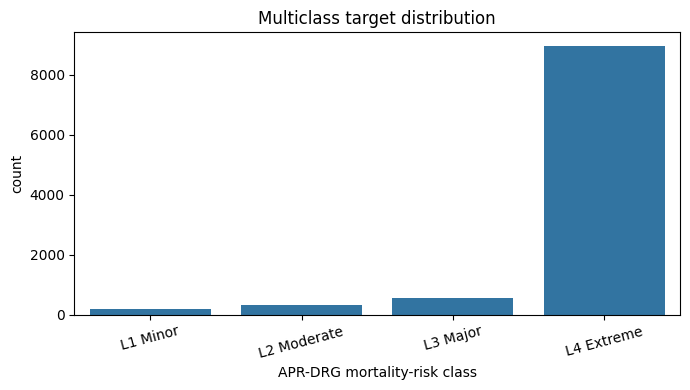

In [8]:
# ------------------------------------------------------------------
# CLEAN MULTICLASS TARGET CREATION
# ------------------------------------------------------------------
before = len(df)
df = df.drop_duplicates().copy()
print(f"Removed {before - len(df):,} exact duplicate rows; {len(df):,} unique rows remain.")

# Keep only valid APR-DRG risk-of-mortality levels 1..4.
raw_target = pd.to_numeric(df[TARGET_SOURCE], errors="coerce")
valid_mask = raw_target.isin([1, 2, 3, 4])
df = df.loc[valid_mask].copy()
df["_drg_level"] = pd.to_numeric(df[TARGET_SOURCE], errors="coerce").astype(np.int64)

PRESENT_LEVELS = sorted(df["_drg_level"].unique().tolist())
assert len(PRESENT_LEVELS) >= 3, (
    "This dataset does not contain enough valid APR-DRG mortality levels for multiclass "
    f"classification. Present levels: {PRESENT_LEVELS}"
)

LEVEL_NAME = {1: "Minor", 2: "Moderate", 3: "Major", 4: "Extreme"}
LEVEL_TO_CLASS = {level: idx for idx, level in enumerate(PRESENT_LEVELS)}
CLASS_TO_LEVEL = {idx: level for level, idx in LEVEL_TO_CLASS.items()}
CLASS_NAMES = [f"L{level} {LEVEL_NAME[level]}" for level in PRESENT_LEVELS]
NUM_CLASSES = len(PRESENT_LEVELS)

# CrossEntropyLoss expects contiguous integer labels 0..K-1.
df["_target_multiclass"] = df["_drg_level"].map(LEVEL_TO_CLASS).astype(np.int64)
target = "_target_multiclass"

CONFIG["target_column"] = target
CONFIG["target_source"] = TARGET_SOURCE
CONFIG["num_classes"] = NUM_CLASSES
CONFIG["present_drg_levels"] = PRESENT_LEVELS
CONFIG["class_names"] = CLASS_NAMES
CONFIG["target_definition"] = (
    "APR-DRG mortality-risk multiclass prediction: " +
    ", ".join(f"level {lvl}={LEVEL_NAME[lvl]}" for lvl in PRESENT_LEVELS)
)

print("Rows with valid APR-DRG mortality level:", len(df))
print("Detected DRG levels:", PRESENT_LEVELS)
print("Number of classes:", NUM_CLASSES)
print("Class mapping:", {i: name for i, name in enumerate(CLASS_NAMES)})
print("Target counts:")
print(df[target].value_counts().sort_index().rename(index={i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}))
print("Target proportions:")
print(df[target].value_counts(normalize=True).sort_index().rename(index={i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}))

# Target sanity check (classification): catch a degenerate/constant target early -
# e.g. a row-limited/sorted read that accidentally grabs a single-class block.
_vc = df[target].value_counts()
assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {_vc.to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
_minority_frac = _vc.min() / _vc.sum()
if _minority_frac < 0.01:
    print(f"[WARNING] Minority class is only {_minority_frac:.2%} of rows - severe class imbalance.")
if len(df) < 100:
    print(f"[WARNING] Only {len(df)} total rows - dataset may be too small for reliable evaluation.")

print("\nGrouped multiclass support audit:")
for col in GROUP_CANDIDATES:
    gmat = (
        df.groupby(col)[target]
          .value_counts()
          .unstack(fill_value=0)
          .reindex(columns=range(NUM_CLASSES), fill_value=0)
    )
    support = (gmat > 0).sum(axis=0)
    print(
        f"  {col}: {len(gmat)} unique groups | groups containing each class = "
        f"{ {CLASS_NAMES[i]: int(support.loc[i]) for i in range(NUM_CLASSES)} }"
    )

plt.figure(figsize=(7, 4))
sns.countplot(x=df[target], order=list(range(NUM_CLASSES)))
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=15)
plt.xlabel("APR-DRG mortality-risk class")
plt.title("Multiclass target distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_target_distribution.png"), dpi=300)
plt.show()


**Data quality memo**


In [9]:
print(
    "Target cleaning complete. The final grouped split and data-quality memo are created "
    "after the class-coverage audit in Section 5."
)


Target cleaning complete. The final grouped split and data-quality memo are created after the class-coverage audit in Section 5.


## 4. Preprocessing & Feature Engineering


In [10]:
# ------------------------------------------------------------------
# LEAKAGE-SAFE FEATURE DEFINITION
# ------------------------------------------------------------------
# Only columns outside the leakage block are eligible.
allowed_cols = [
    c for c in df.columns
    if c not in LEAKAGE_COLS and c not in {target, "_drg_level"}
]

# Explicit text fields. We intentionally do NOT fall back to joining every column,
# because that previously concatenated target/DRG fields directly into the model input.
TEXT_FEATURE_COLS = [
    c for c in [
        "comments", "test_name", "org_name", "ab_name", "spec_type_desc",
        "drug", "formulary_drug_cd"
    ]
    if c in allowed_cols
]
print("Text feature columns:", TEXT_FEATURE_COLS)

# Use a non-target-derived clinical context category as the graph node.
graph_candidates = [c for c in ["careunit", "admission_type", "admission_location", "route"] if c in allowed_cols]
diag_col_for_graph = None
for c in graph_candidates:
    nunique = df[c].nunique(dropna=True)
    if 1 < nunique <= 200:
        diag_col_for_graph = c
        break
print("Clinical context column used for graph node:", diag_col_for_graph)

if diag_col_for_graph:
    df["_diag_node"] = df[diag_col_for_graph].fillna("missing").astype(str)
else:
    df["_diag_node"] = "none"

# `_diag_node` is a derived graph index, not a separate tabular feature.
model_candidate_cols = [c for c in allowed_cols if c != "_diag_node"]

numeric_cols = [
    c for c in model_candidate_cols
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) > 1
]

categorical_cols = [
    c for c in model_candidate_cols
    if c not in numeric_cols
    and c not in TEXT_FEATURE_COLS
    and df[c].dtype == object
    and 1 < df[c].nunique(dropna=True) <= 50
]

# Defensive assertions: fail loudly if a prohibited field slips back into the model.
used_feature_cols = set(numeric_cols) | set(categorical_cols) | set(TEXT_FEATURE_COLS)
forbidden_used = used_feature_cols & LEAKAGE_COLS
assert not forbidden_used, f"LEAKAGE DETECTED in features: {sorted(forbidden_used)}"
assert TARGET_SOURCE not in used_feature_cols and target not in used_feature_cols
assert "_drg_level" not in used_feature_cols

print("Numeric features:", numeric_cols)
print("Categorical features (<=50 unique):", categorical_cols)
print("Blocked leakage fields present in model:", sorted(forbidden_used))


Text feature columns: ['comments', 'test_name', 'org_name', 'ab_name', 'spec_type_desc', 'drug', 'formulary_drug_cd']
Clinical context column used for graph node: careunit
Numeric features: ['anchor_age', 'dose_val_rx']
Categorical features (<=50 unique): ['admission_type', 'admission_location', 'insurance', 'marital_status', 'race', 'gender', 'prod_strength', 'dose_unit_rx', 'form_unit_disp', 'route', 'eventtype', 'careunit', 'order_type', 'order_subtype', 'transaction_type']
Blocked leakage fields present in model: []


## 5. Train / Validation / Test Split


In [11]:
# ------------------------------------------------------------------
# LEAKAGE-SAFE GROUPED SPLIT WITH STRICT MULTICLASS COVERAGE
# ------------------------------------------------------------------
ratios = CONFIG["split_ratios"]
ALL_CLASSES = set(range(NUM_CLASSES))

def _counts_array(gmat, row_indices):
    if len(row_indices) == 0:
        return np.zeros(NUM_CLASSES, dtype=np.int64)
    return gmat.iloc[row_indices].to_numpy(dtype=np.int64).sum(axis=0)

def _search_grouped_split(group_col, max_tries=2000):
    """
    Search for a grouped train/val/test split in which EVERY detected class
    appears in all three partitions. No row-level random split is permitted.
    """
    gmat = (
        df.groupby(group_col)[target]
          .value_counts()
          .unstack(fill_value=0)
          .reindex(columns=range(NUM_CLASSES), fill_value=0)
    )
    group_ids = gmat.index.to_numpy()
    support = (gmat > 0).sum(axis=0).to_numpy()

    diagnostics = {
        "group_col": group_col,
        "n_groups": int(len(group_ids)),
        "groups_per_class": {CLASS_NAMES[i]: int(support[i]) for i in range(NUM_CLASSES)},
    }

    # At least 3 distinct groups must contain every class to place that class
    # in train, validation and test without group overlap.
    if len(group_ids) < 3 or np.any(support < 3):
        diagnostics["reason"] = (
            "At least 3 distinct groups containing every class are required for "
            "train/validation/test class coverage."
        )
        return None, diagnostics

    overall = gmat.to_numpy(dtype=np.float64).sum(axis=0)
    overall_dist = overall / max(overall.sum(), 1.0)

    group_table = pd.DataFrame({"group_id": group_ids})
    best = None
    best_score = float("inf")

    for attempt in range(max_tries):
        seed1 = SEED + attempt
        try:
            gss1 = GroupShuffleSplit(
                n_splits=1, train_size=ratios["train"], random_state=seed1
            )
            tr_idx, rest_idx = next(
                gss1.split(group_table, groups=group_table["group_id"])
            )
        except ValueError:
            continue

        if len(rest_idx) < 2:
            continue

        rest_table = group_table.iloc[rest_idx].reset_index(drop=True)
        rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
        try:
            gss2 = GroupShuffleSplit(
                n_splits=1, train_size=rel_val, random_state=SEED + 10000 + attempt
            )
            rv_idx, rt_idx = next(
                gss2.split(rest_table, groups=rest_table["group_id"])
            )
        except ValueError:
            continue

        val_idx = rest_idx[rv_idx]
        test_idx = rest_idx[rt_idx]

        tr_counts = _counts_array(gmat, tr_idx)
        va_counts = _counts_array(gmat, val_idx)
        te_counts = _counts_array(gmat, test_idx)

        # Strict multiclass requirement.
        if np.any(tr_counts == 0) or np.any(va_counts == 0) or np.any(te_counts == 0):
            continue

        # Prefer class distributions and row ratios close to the full dataset.
        score = 0.0
        for counts in [tr_counts, va_counts, te_counts]:
            dist = counts / max(counts.sum(), 1)
            score += float(np.abs(dist - overall_dist).mean())

        total_rows = overall.sum()
        observed_ratios = np.array([
            tr_counts.sum() / total_rows,
            va_counts.sum() / total_rows,
            te_counts.sum() / total_rows,
        ])
        desired_ratios = np.array([ratios["train"], ratios["val"], ratios["test"]])
        score += 2.0 * float(np.abs(observed_ratios - desired_ratios).mean())

        if score < best_score:
            best_score = score
            best = {
                "train_groups": set(group_ids[tr_idx].tolist()),
                "val_groups": set(group_ids[val_idx].tolist()),
                "test_groups": set(group_ids[test_idx].tolist()),
                "train_counts": tr_counts,
                "val_counts": va_counts,
                "test_counts": te_counts,
                "score": score,
                "attempt": attempt,
            }

    if best is None:
        diagnostics["reason"] = (
            f"No valid all-class grouped split found after {max_tries} attempts."
        )
    return best, diagnostics


split_candidate = None
split_diagnostics = []

# Prefer subject-level separation. Only if impossible do we try admission-level.
for candidate_col in GROUP_CANDIDATES:
    candidate, diag = _search_grouped_split(candidate_col, max_tries=2000)
    split_diagnostics.append(diag)
    print(f"\nSplit audit for {candidate_col}:")
    print(json.dumps(diag, indent=2))
    if candidate is not None:
        GROUP_COL = candidate_col
        split_candidate = candidate
        break

if split_candidate is None and NUM_CLASSES == 4:
    # Tiny cohort cannot place L1 in all three grouped partitions. Merge adjacent
    # low-risk levels, preserving ordinal meaning and group-leakage protection.
    df[target] = df['_drg_level'].map({1: 0, 2: 0, 3: 1, 4: 2}).astype(np.int64)
    CLASS_NAMES = ['L1-L2 Lower', 'L3 Major', 'L4 Extreme']
    NUM_CLASSES = 3
    ALL_CLASSES = set(range(NUM_CLASSES))
    CONFIG['num_classes'] = NUM_CLASSES
    CONFIG['class_names'] = CLASS_NAMES
    CONFIG['target_definition'] = 'APR-DRG mortality-risk: lower (levels 1-2), major (3), extreme (4)'
    split_diagnostics = []
    for candidate_col in GROUP_CANDIDATES:
        candidate, diag = _search_grouped_split(candidate_col, max_tries=2000)
        split_diagnostics.append(diag)
        if candidate is not None:
            GROUP_COL, split_candidate = candidate_col, candidate
            break

if split_candidate is None and NUM_CLASSES == 3:
    # Still too few groups for 3-class coverage. Collapse further into a
    # binary lower-risk vs higher-risk target, preserving ordinal meaning
    # and group-leakage protection (same pattern as the 4-class fallback above).
    df[target] = df['_drg_level'].map({1: 0, 2: 0, 3: 1, 4: 1}).astype(np.int64)
    CLASS_NAMES = ['Lower Risk (L1-L2)', 'Higher Risk (L3-L4)']
    NUM_CLASSES = 2
    ALL_CLASSES = set(range(NUM_CLASSES))
    CONFIG['num_classes'] = NUM_CLASSES
    CONFIG['class_names'] = CLASS_NAMES
    CONFIG['target_definition'] = 'APR-DRG mortality-risk: lower (levels 1-2) vs higher (levels 3-4)'
    split_diagnostics = []
    for candidate_col in GROUP_CANDIDATES:
        candidate, diag = _search_grouped_split(candidate_col, max_tries=2000)
        split_diagnostics.append(diag)
        if candidate is not None:
            GROUP_COL, split_candidate = candidate_col, candidate
            break

if split_candidate is None:
    diagnostic_text = json.dumps(split_diagnostics, indent=2)
    raise RuntimeError(
        "This filtered dataset cannot support a trustworthy multiclass train/validation/test "
        "split with every class represented in every partition without group leakage.\n\n"
        "The previous 100% result happened because the test set contained only one class. "
        "A random row split would hide the problem by leaking repeated patient/admission records, "
        "so this notebook intentionally refuses to do that.\n\n"
        f"Split diagnostics:\n{diagnostic_text}\n\n"
        "Use a larger MIMIC-IV cohort with more patients/admissions per APR-DRG class, "
        "or change the research target/dataset."
    )

train_groups = split_candidate["train_groups"]
val_groups = split_candidate["val_groups"]
test_groups = split_candidate["test_groups"]

train_df = df[df[GROUP_COL].isin(train_groups)].copy()
val_df = df[df[GROUP_COL].isin(val_groups)].copy()
test_df = df[df[GROUP_COL].isin(test_groups)].copy()

# Hard group leakage checks.
assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

# Hard multiclass coverage checks.
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    present = set(split_df[target].unique().tolist())
    missing = ALL_CLASSES - present
    assert not missing, (
        f"{split_name} split is missing classes "
        f"{[CLASS_NAMES[i] for i in sorted(missing)]}. Evaluation would be invalid."
    )

CONFIG["split_group_col"] = GROUP_COL
CONFIG["split_group_level"] = "patient" if GROUP_COL == "subject_id" else "admission"

print("\nSELECTED GROUPING:", GROUP_COL)
if GROUP_COL == "subject_id":
    print("Patient-independent split achieved.")
else:
    print(
        "WARNING: Patient-level 4-class splitting is impossible in this cleaned subset, "
        "so an admission-grouped split is used. This prevents admission-row leakage, but "
        "the same patient may occur in different splits; interpret results as admission-level "
        "generalization, not unseen-patient generalization."
    )

print("Train / Val / Test rows:", len(train_df), len(val_df), len(test_df))
print("Train / Val / Test groups:", len(train_groups), len(val_groups), len(test_groups))

split_class_counts = {}
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df[target].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()
    split_class_counts[split_name] = {CLASS_NAMES[i]: int(counts.loc[i]) for i in range(NUM_CLASSES)}
    print(f"{split_name} class counts:", split_class_counts[split_name])

# Report patient overlap separately even if grouping is by admission.
patient_overlap = {"train_val": None, "train_test": None, "val_test": None}
if "subject_id" in df.columns:
    p_train = set(train_df["subject_id"].dropna().unique().tolist())
    p_val = set(val_df["subject_id"].dropna().unique().tolist())
    p_test = set(test_df["subject_id"].dropna().unique().tolist())
    patient_overlap = {
        "train_val": len(p_train & p_val),
        "train_test": len(p_train & p_test),
        "val_test": len(p_val & p_test),
    }
    print("Patient overlap train-val/train-test/val-test:", patient_overlap)

manifest = {
    "split_method": "strict grouped split with full multiclass coverage",
    "group_column": GROUP_COL,
    "group_level": CONFIG["split_group_level"],
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_groups": len(train_groups),
    "val_groups": len(val_groups),
    "test_groups": len(test_groups),
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "split_class_counts": split_class_counts,
    "group_overlap": {"train_val": 0, "train_test": 0, "val_test": 0},
    "patient_overlap": patient_overlap,
    "search_score": float(split_candidate["score"]),
    "search_attempt": int(split_candidate["attempt"]),
}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)

train_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)

# Final data-quality memo is written only AFTER the split is proven valid.
split_interpretation = (
    "Patient-independent evaluation."
    if GROUP_COL == "subject_id"
    else (
        "Admission-grouped evaluation. Admission rows never cross partitions, but the same "
        "patient may occur in different partitions because this cleaned subset contains too few "
        "patients for a valid 4-class patient-level split."
    )
)

data_quality_memo = f"""# Data Quality Memo - Project 21: Explainable EHR Graph Risk Prediction

## Dataset
- Source: MIMIC-IV cleaned medical transcripts ({RAW_FILE})
- Rows after exact de-duplication and valid-target filtering: {len(df)}
- Target source: {TARGET_SOURCE}
- Target definition: {CONFIG['target_definition']}
- Number of detected classes: {NUM_CLASSES}
- Detected APR-DRG levels: {PRESENT_LEVELS}
- Selected split key: {GROUP_COL} ({CONFIG['split_group_level']}-level)

## Why the previous 100% result was invalid
The previous patient-grouped run had only 7 patients after target filtering. Its test set contained
only L4 Extreme, so a majority predictor scored 100% even though no real four-class discrimination
was being tested.

## Leakage and evaluation controls
1. Exact duplicate rows are removed before splitting.
2. Missing/invalid DRG mortality values are dropped rather than mapped to a class.
3. `subject_id` and `hadm_id` are excluded from model features.
4. DRG target-family fields (`drg_mortality`, `drg_severity`, `drg_type`, `description`) are excluded.
5. `discharge_location` is excluded because it is post-outcome information.
6. No selected split-group (`{GROUP_COL}`) appears in more than one partition.
7. Every detected class must occur in train, validation, and test; otherwise execution stops.
8. Text is built only from explicitly allowed clinical-event fields.
9. Imputation, scaling, categorical encoding, vocabularies, and graph-node mappings are fitted on training data only.

## Split interpretation
{split_interpretation}

## Interpretation note
`drg_mortality` is an APR-DRG mortality-risk category, not observed patient death.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print("\n" + data_quality_memo)
manifest



Split audit for subject_id:
{
  "group_col": "subject_id",
  "n_groups": 7,
  "groups_per_class": {
    "L1 Minor": 2,
    "L2 Moderate": 1,
    "L3 Major": 2,
    "L4 Extreme": 4
  },
  "reason": "At least 3 distinct groups containing every class are required for train/validation/test class coverage."
}

Split audit for hadm_id:
{
  "group_col": "hadm_id",
  "n_groups": 12,
  "groups_per_class": {
    "L1 Minor": 2,
    "L2 Moderate": 3,
    "L3 Major": 3,
    "L4 Extreme": 4
  },
  "reason": "At least 3 distinct groups containing every class are required for train/validation/test class coverage."
}



SELECTED GROUPING: subject_id
Patient-independent split achieved.
Train / Val / Test rows: 7900 780 1343
Train / Val / Test groups: 4 1 2
train class counts: {'Lower Risk (L1-L2)': 327, 'Higher Risk (L3-L4)': 7573}
val class counts: {'Lower Risk (L1-L2)': 120, 'Higher Risk (L3-L4)': 660}
test class counts: {'Lower Risk (L1-L2)': 68, 'Higher Risk (L3-L4)': 1275}
Patient overlap train-val/train-test/val-test: {'train_val': 0, 'train_test': 0, 'val_test': 0}

# Data Quality Memo - Project 21: Explainable EHR Graph Risk Prediction

## Dataset
- Source: MIMIC-IV cleaned medical transcripts (data/21/raw/MIMIC_IV_Trasncript.csv)
- Rows after exact de-duplication and valid-target filtering: 10023
- Target source: drg_mortality
- Target definition: APR-DRG mortality-risk: lower (levels 1-2) vs higher (levels 3-4)
- Number of detected classes: 2
- Detected APR-DRG levels: [1, 2, 3, 4]
- Selected split key: subject_id (patient-level)

## Why the previous 100% result was invalid
The previous pati

{'split_method': 'strict grouped split with full multiclass coverage',
 'group_column': 'subject_id',
 'group_level': 'patient',
 'train_rows': 7900,
 'val_rows': 780,
 'test_rows': 1343,
 'train_groups': 4,
 'val_groups': 1,
 'test_groups': 2,
 'num_classes': 2,
 'class_names': ['Lower Risk (L1-L2)', 'Higher Risk (L3-L4)'],
 'split_class_counts': {'train': {'Lower Risk (L1-L2)': 327,
   'Higher Risk (L3-L4)': 7573},
  'val': {'Lower Risk (L1-L2)': 120, 'Higher Risk (L3-L4)': 660},
  'test': {'Lower Risk (L1-L2)': 68, 'Higher Risk (L3-L4)': 1275}},
 'group_overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0},
 'patient_overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0},
 'search_score': 0.230785551880464,
 'search_attempt': 5}

In [12]:

# ------------------------------------------------------------------
# TRAIN-ONLY PREPROCESSING
# ------------------------------------------------------------------
if numeric_cols:
    imputer = SimpleImputer(strategy="median").fit(train_df[numeric_cols])
    scaler = StandardScaler()

    train_num = imputer.transform(train_df[numeric_cols])
    val_num = imputer.transform(val_df[numeric_cols])
    test_num = imputer.transform(test_df[numeric_cols])

    scaler.fit(train_num)
    train_num = scaler.transform(train_num)
    val_num = scaler.transform(val_num)
    test_num = scaler.transform(test_num)

    train_num_df = pd.DataFrame(train_num, columns=numeric_cols, index=train_df.index)
    val_num_df = pd.DataFrame(val_num, columns=numeric_cols, index=val_df.index)
    test_num_df = pd.DataFrame(test_num, columns=numeric_cols, index=test_df.index)
else:
    train_num_df = val_num_df = test_num_df = None

# Do not mutate the source split frames in-place for encoding.
if categorical_cols:
    train_cat = train_df[categorical_cols].fillna("missing").astype(str)
    val_cat = val_df[categorical_cols].fillna("missing").astype(str)
    test_cat = test_df[categorical_cols].fillna("missing").astype(str)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train_cat)
    cat_names = encoder.get_feature_names_out(categorical_cols).tolist()

    train_cat_df = pd.DataFrame(encoder.transform(train_cat), columns=cat_names, index=train_df.index)
    val_cat_df = pd.DataFrame(encoder.transform(val_cat), columns=cat_names, index=val_df.index)
    test_cat_df = pd.DataFrame(encoder.transform(test_cat), columns=cat_names, index=test_df.index)
else:
    encoder = None
    cat_names = []
    train_cat_df = val_cat_df = test_cat_df = None

def combine_tabular(num_df, cat_df, split_index):
    parts = []
    if num_df is not None:
        parts.append(num_df.reset_index(drop=True))
    if cat_df is not None:
        parts.append(cat_df.reset_index(drop=True))
    if not parts:
        return pd.DataFrame({"_bias": np.ones(len(split_index), dtype=np.float32)})
    return pd.concat(parts, axis=1)

train_tab = combine_tabular(train_num_df, train_cat_df, train_df.index)
val_tab = combine_tabular(val_num_df, val_cat_df, val_df.index)
test_tab = combine_tabular(test_num_df, test_cat_df, test_df.index)
print("Tabular feature dim:", train_tab.shape[1])

# ------------------ Safe text construction ------------------
from collections import Counter
import re as _re

def make_text(row):
    if not TEXT_FEATURE_COLS:
        return ""
    vals = []
    for c in TEXT_FEATURE_COLS:
        v = row[c]
        if pd.notna(v):
            vals.append(str(v))
    return " ".join(vals)

def tokenize(s):
    return _re.findall(r"[a-z0-9]+", str(s).lower())

word_counts = Counter()
for _, row in train_df.iterrows():
    word_counts.update(tokenize(make_text(row)))

# Reserve an explicit <empty> token so no Transformer sample is 100% padding.
vocab = ["<pad>", "<unk>", "<empty>"] + [
    w for w, _ in word_counts.most_common(max(CONFIG["max_vocab"] - 3, 0))
]
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = max(len(vocab), 3)

def encode_text(row):
    ids = [word_to_idx.get(w, 1) for w in tokenize(make_text(row))[:CONFIG["max_text_len"]]]
    if not ids:
        ids = [word_to_idx["<empty>"]]
    return ids + [0] * (CONFIG["max_text_len"] - len(ids))

# Graph-node vocabulary from TRAIN only.
diag_nodes = sorted(train_df["_diag_node"].unique())
diag_to_idx = {d: i for i, d in enumerate(diag_nodes)}
N_DIAG_NODES = len(diag_nodes) + 1

# Final defensive audit.
assert TARGET_SOURCE not in numeric_cols
assert TARGET_SOURCE not in categorical_cols
assert TARGET_SOURCE not in TEXT_FEATURE_COLS
assert "drg_severity" not in numeric_cols + categorical_cols + TEXT_FEATURE_COLS
assert "drg_type" not in numeric_cols + categorical_cols + TEXT_FEATURE_COLS
assert "description" not in numeric_cols + categorical_cols + TEXT_FEATURE_COLS

print("Vocab size:", VOCAB_SIZE, "| Graph/context nodes:", N_DIAG_NODES)
print("Leakage audit: PASSED")


Tabular feature dim: 138


Vocab size: 401 | Graph/context nodes: 10
Leakage audit: PASSED


## 6. PyTorch Dataset & DataLoader


In [13]:
class EHRTextDataset(Dataset):
    def __init__(self, split_df, tab_df):
        # Pre-create contiguous tensors once instead of constructing new tensors for every
        # sample in every epoch. This reduces CPU overhead and keeps the GPU fed faster.
        self.text_ids = torch.as_tensor(
            np.asarray([encode_text(row) for _, row in split_df.iterrows()], dtype=np.int64),
            dtype=torch.long
        )
        self.diag = torch.as_tensor(
            np.asarray([diag_to_idx.get(v, N_DIAG_NODES - 1) for v in split_df["_diag_node"]], dtype=np.int64),
            dtype=torch.long
        )
        self.tab = torch.as_tensor(tab_df.values.astype(np.float32), dtype=torch.float32)
        self.y = torch.as_tensor(split_df[target].values.astype(np.int64), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.text_ids[idx], self.diag[idx], self.tab[idx], self.y[idx]

BATCH_SIZE = CONFIG["batch_size"]
NUM_WORKERS = int(CONFIG.get("num_workers", 0))
PIN_MEMORY = bool(CONFIG.get("pin_memory", True)) and DEVICE.type == "cuda"

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs.update({"persistent_workers": True, "prefetch_factor": 2})

train_ds = EHRTextDataset(train_df, train_tab)
val_ds = EHRTextDataset(val_df, val_tab)
test_ds = EHRTextDataset(test_df, test_tab)
train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

xb_text, xb_diag, xb_tab, yb = next(iter(train_loader))
print("text:", xb_text.shape, "diag:", xb_diag.shape, "tab:", xb_tab.shape, "target:", yb.shape)
print(f"DataLoader: batch_size={BATCH_SIZE}, workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}")
TAB_DIM = xb_tab.shape[1]


text: torch.Size([128, 150]) diag: torch.Size([128]) tab: torch.Size([128, 138]) target: torch.Size([128])
DataLoader: batch_size=128, workers=2, pin_memory=True


## 7. Model Definitions


In [14]:
class ClinicalTemporalTransformer(nn.Module):
    """Self-attention over the case's own clinical field/token sequence (documented substitute for
    a real multi-visit timeline, since this table is one row per case - see header)."""
    def __init__(self, vocab_size, hidden_dim=64, n_heads=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        layer = nn.TransformerEncoderLayer(hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = hidden_dim
    def forward(self, x_text):
        h = self.embed(x_text)
        pad_mask = (x_text == 0)
        h = self.encoder(h, src_key_padding_mask=pad_mask)

        # Mean-pool only real tokens. encode_text() guarantees at least one
        # non-padding token, preventing all-masked attention/NaN behaviour.
        valid = (~pad_mask).unsqueeze(-1).to(h.dtype)
        denom = valid.sum(dim=1).clamp_min(1.0)
        return (h * valid).sum(dim=1) / denom


class HeterogeneousGAT(nn.Module):
    """Attention-weighted fusion of the case's own tabular representation and its diagnosis-node
    embedding (real bipartite case<->diagnosis-category graph, documented substitute for a full
    clinical knowledge graph - see header)."""
    def __init__(self, n_diag_nodes, tab_dim, hidden_dim=32):
        super().__init__()
        self.diag_embed = nn.Embedding(n_diag_nodes, hidden_dim)
        self.tab_proj = nn.Linear(max(tab_dim, 1), hidden_dim)
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.out_dim = hidden_dim
    def forward(self, x_diag, x_tab):
        h_tab = self.tab_proj(x_tab)
        h_diag = self.diag_embed(x_diag)
        score = torch.sigmoid(self.attn(torch.cat([h_tab, h_diag], dim=-1)))
        return F.relu(h_tab + score * h_diag)


class HybridModel(nn.Module):
    def __init__(self, vocab_size, n_diag_nodes, tab_dim, transformer_hidden=64, gat_hidden=32, output_dim=NUM_CLASSES):
        super().__init__()
        self.temporal = ClinicalTemporalTransformer(vocab_size, transformer_hidden)
        self.gat = HeterogeneousGAT(n_diag_nodes, tab_dim, gat_hidden)
        self.head = nn.Sequential(nn.Linear(transformer_hidden + gat_hidden, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, output_dim))
    def forward(self, x_text, x_diag, x_tab):
        h_t = self.temporal(x_text)
        h_g = self.gat(x_diag, x_tab)
        return self.head(torch.cat([h_t, h_g], dim=-1))


### Architecture Verification


In [15]:
hybrid = HybridModel(VOCAB_SIZE, N_DIAG_NODES, TAB_DIM, CONFIG['transformer_hidden'], CONFIG['gat_hidden'], output_dim=NUM_CLASSES).to(DEVICE)
print('NUM_CLASSES:', NUM_CLASSES, CLASS_NAMES)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


NUM_CLASSES: 2 ['Lower Risk (L1-L2)', 'Higher Risk (L3-L4)']
HybridModel(
  (temporal): ClinicalTemporalTransformer(
    (embed): Embedding(401, 64, padding_idx=0)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (gat): HeterogeneousGAT(
    (diag_embed): Embedding(10, 32)
    (tab_proj): Linear(in_features=138

## 8. Training Loop


In [16]:
def train_model(model, train_loader, val_loader, epochs, lr, patience, ckpt_path, class_weights=None):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    use_amp = bool(CONFIG.get('use_amp', True)) and DEVICE.type == 'cuda'
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc=f'Training multiclass on {DEVICE}', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n = 0
        batch_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, unit='batch')
        for xt, xd, xta, y in batch_bar:
            xt = xt.to(DEVICE, non_blocking=True)
            xd = xd.to(DEVICE, non_blocking=True)
            xta = xta.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).long()
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = model(xt, xd, xta)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.detach().item() * y.shape[0]
            n += y.shape[0]
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')
        train_loss /= max(n, 1)
        model.eval()
        val_loss = 0.0
        nv = 0
        with torch.inference_mode():
            for xt, xd, xta, y in val_loader:
                xt = xt.to(DEVICE, non_blocking=True)
                xd = xd.to(DEVICE, non_blocking=True)
                xta = xta.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True).long()
                with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                    logits = model(xt, xd, xta)
                    loss = criterion(logits, y)
                val_loss += loss.item() * y.shape[0]
                nv += y.shape[0]
        val_loss /= max(nv, 1)
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}', amp=use_amp)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    return history
class_counts = np.bincount(train_df[target].to_numpy(dtype=np.int64), minlength=NUM_CLASSES)
assert np.all(class_counts > 0), f'A class is missing from train split: {class_counts}'
class_weights_np = len(train_df) / (NUM_CLASSES * class_counts.astype(np.float64))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)
print('Train class counts:', {CLASS_NAMES[i]: int(class_counts[i]) for i in range(NUM_CLASSES)})
print('CrossEntropy class weights:', {CLASS_NAMES[i]: float(class_weights_np[i]) for i in range(NUM_CLASSES)})
print('Mixed precision (AMP):', bool(CONFIG.get('use_amp', True)) and DEVICE.type == 'cuda')
hybrid_history = train_model(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), class_weights)


Train class counts: {'Lower Risk (L1-L2)': 327, 'Higher Risk (L3-L4)': 7573}
CrossEntropy class weights: {'Lower Risk (L1-L2)': 12.079510703363914, 'Higher Risk (L3-L4)': 0.5215898587085699}
Mixed precision (AMP): True


Training multiclass on cuda:0:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 2/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 3/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 4/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 5/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 6/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Epoch 7/30:   0%|          | 0/62 [00:00<?, ?batch/s]

Early stopping at epoch 7


## 9. Evaluation Metrics


In [17]:
def get_predictions(model, loader, ckpt_path):
    model.to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    all_probs, all_targets = [], []
    use_amp = bool(CONFIG.get("use_amp", True)) and DEVICE.type == "cuda"

    with torch.inference_mode():
        for xt, xd, xta, y in loader:
            xt = xt.to(DEVICE, non_blocking=True)
            xd = xd.to(DEVICE, non_blocking=True)
            xta = xta.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                logits = model(xt, xd, xta)
                probs = torch.softmax(logits.float(), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.numpy().astype(np.int64))

    return np.concatenate(all_probs, axis=0), np.concatenate(all_targets, axis=0)


def evaluate_classification(probs, targets, split_name="evaluation"):
    targets = np.asarray(targets, dtype=np.int64)
    probs = np.asarray(probs, dtype=np.float64)

    expected = set(range(NUM_CLASSES))
    present = set(np.unique(targets).tolist())
    missing = expected - present
    if missing:
        raise RuntimeError(
            f"{split_name} is missing classes {[CLASS_NAMES[i] for i in sorted(missing)]}. "
            "Multiclass accuracy/F1/AUC from this split would be misleading, so evaluation stopped."
        )

    assert probs.ndim == 2 and probs.shape[1] == NUM_CLASSES, (
        f"Expected probability matrix [N,{NUM_CLASSES}], got {probs.shape}"
    )

    pred_labels = probs.argmax(axis=1)
    labels = list(range(NUM_CLASSES))

    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, pred_labels, labels=labels, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        targets, pred_labels, labels=labels, average="weighted", zero_division=0
    )

    y_onehot = np.eye(NUM_CLASSES, dtype=np.int64)[targets]

    metrics = {
        "accuracy": float(accuracy_score(targets, pred_labels)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "f1_weighted": float(f1_weighted),
        "mcc": float(matthews_corrcoef(targets, pred_labels)),
        "roc_auc_ovr_macro": float(
            roc_auc_score(targets, probs[:, 1], average="macro")
            if NUM_CLASSES == 2
            else roc_auc_score(targets, probs, multi_class="ovr", average="macro")
        ),
        "pr_auc_ovr_macro": float(
            average_precision_score(y_onehot, probs, average="macro")
        ),
    }
    return metrics


In [18]:
results = {}
test_predictions = {}
test_present = set(test_df[target].unique().tolist())
missing_test = set(range(NUM_CLASSES)) - test_present
assert not missing_test, 'Invalid test split: missing ' + str([CLASS_NAMES[i] for i in sorted(missing_test)])
print('Test class distribution:', {CLASS_NAMES[i]: int((test_df[target] == i).sum()) for i in range(NUM_CLASSES)})
for name, model, ckpt in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]:
    probs, targets_eval = get_predictions(model, test_loader, ckpt)
    results[name] = evaluate_classification(probs, targets_eval, split_name='test')
    test_predictions[name] = (probs, targets_eval)
print(json.dumps(results, indent=2, default=str))
if results['hybrid']['accuracy'] >= 0.99 or results['hybrid']['roc_auc_ovr_macro'] >= 0.999:
    print('\nWARNING: Near-perfect held-out multiclass performance detected. Do not report it until feature provenance and split-group independence are manually re-audited.')
if results['hybrid']['accuracy'] - results['hybrid']['f1_macro'] > 0.2:
    print('\nIMPORTANT: Accuracy is much higher than macro-F1. The dataset is highly imbalanced, so use macro-F1, per-class recall and multiclass AUC alongside accuracy.')
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


Test class distribution: {'Lower Risk (L1-L2)': 68, 'Higher Risk (L3-L4)': 1275}


{
  "hybrid": {
    "accuracy": 0.9426656738644825,
    "precision_macro": 0.4745127436281859,
    "recall_macro": 0.4964705882352941,
    "f1_macro": 0.4852433882713683,
    "f1_weighted": 0.9213482055785474,
    "mcc": -0.018968924322560372,
    "roc_auc_ovr_macro": 0.75560553633218,
    "pr_auc_ovr_macro": 0.5631855772098179
  }
}

IMPORTANT: Accuracy is much higher than macro-F1. The dataset is highly imbalanced, so use macro-F1, per-class recall and multiclass AUC alongside accuracy.


## 10. Required Figures


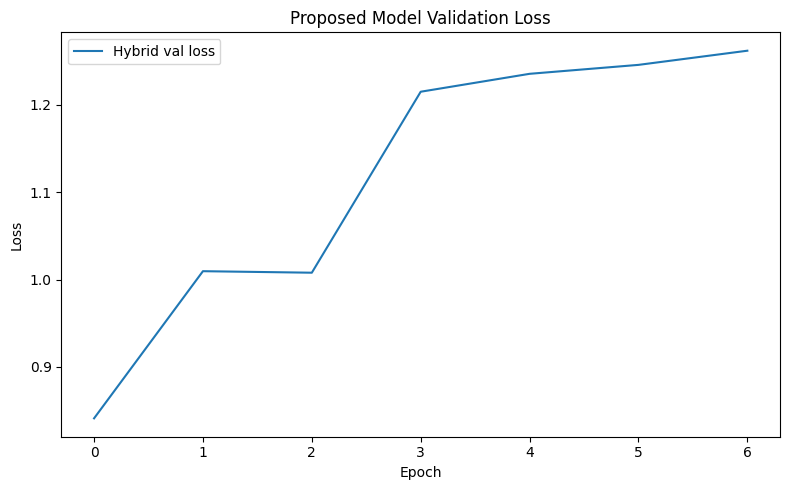

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


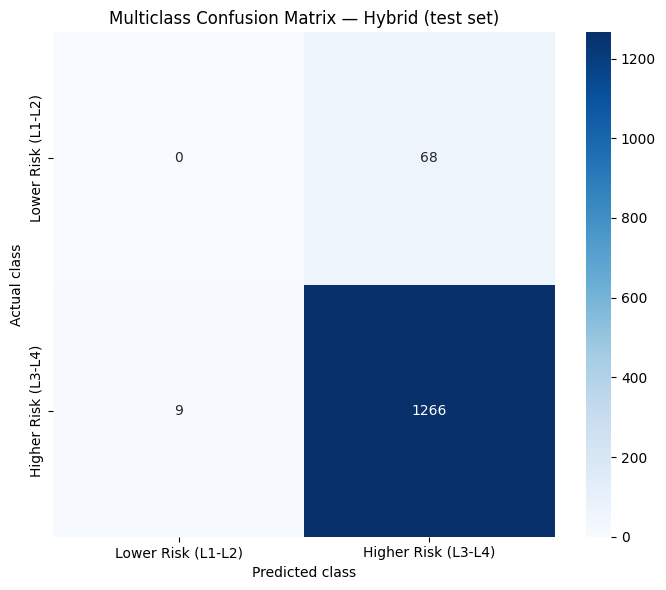

In [20]:
hybrid_probs, hybrid_targets = test_predictions["hybrid"]
hybrid_pred_labels = hybrid_probs.argmax(axis=1)

plt.figure(figsize=(7, 6))
cm = confusion_matrix(hybrid_targets, hybrid_pred_labels, labels=list(range(NUM_CLASSES)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Multiclass Confusion Matrix — Hybrid (test set)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300)
plt.show()


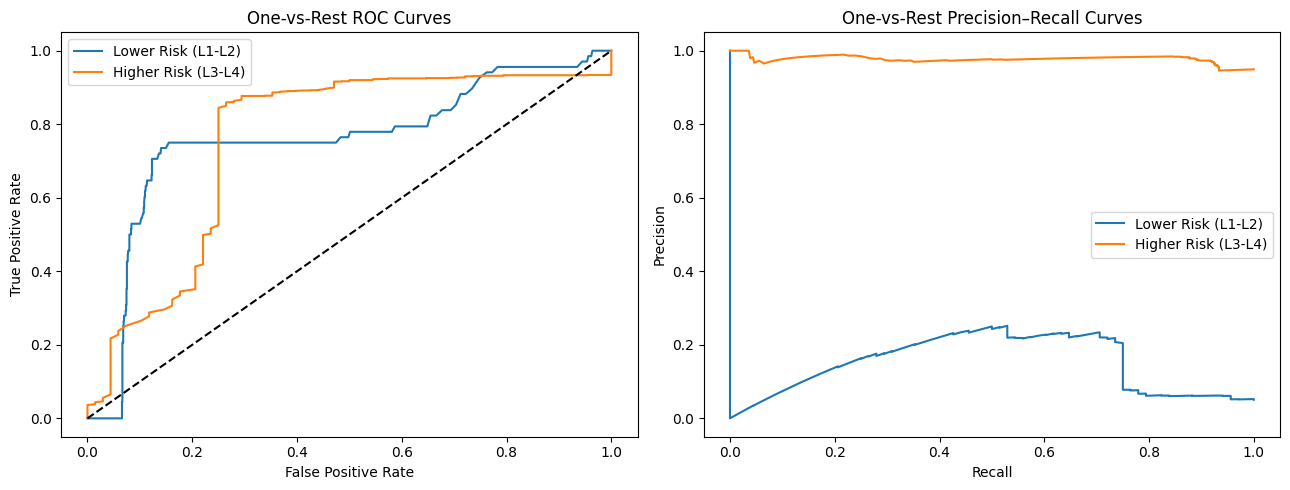

In [21]:
y_onehot = np.eye(NUM_CLASSES, dtype=np.int64)[hybrid_targets]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, class_name in enumerate(CLASS_NAMES):
    y_bin = y_onehot[:, i]
    if len(np.unique(y_bin)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_bin, hybrid_probs[:, i])
    precision, recall, _ = precision_recall_curve(y_bin, hybrid_probs[:, i])
    axes[0].plot(fpr, tpr, label=class_name)
    axes[1].plot(recall, precision, label=class_name)

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("One-vs-Rest ROC Curves")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("One-vs-Rest Precision–Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300)
plt.show()


### Explainable AI — Heterogeneous GAT Attention Gate


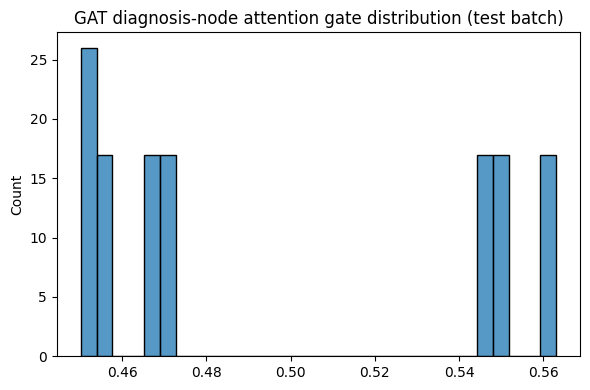

In [22]:
hybrid.eval()
with torch.no_grad():
    xt_e, xd_e, xta_e, _ = next(iter(test_loader))
    h_tab = hybrid.gat.tab_proj(xta_e.to(DEVICE, non_blocking=True))
    h_diag = hybrid.gat.diag_embed(xd_e.to(DEVICE, non_blocking=True))
    gate = torch.sigmoid(hybrid.gat.attn(torch.cat([h_tab, h_diag], dim=-1))).cpu().numpy().ravel()

plt.figure(figsize=(6, 4))
sns.histplot(gate, bins=30)
plt.title("GAT diagnosis-node attention gate distribution (test batch)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300); plt.show()


### Error Analysis


Misclassified test rows: 77 / 1,343 (5.73%)
Most common confusion pairs:
actual               predicted          
Lower Risk (L1-L2)   Higher Risk (L3-L4)    68
Higher Risk (L3-L4)  Lower Risk (L1-L2)      9
Name: count, dtype: int64


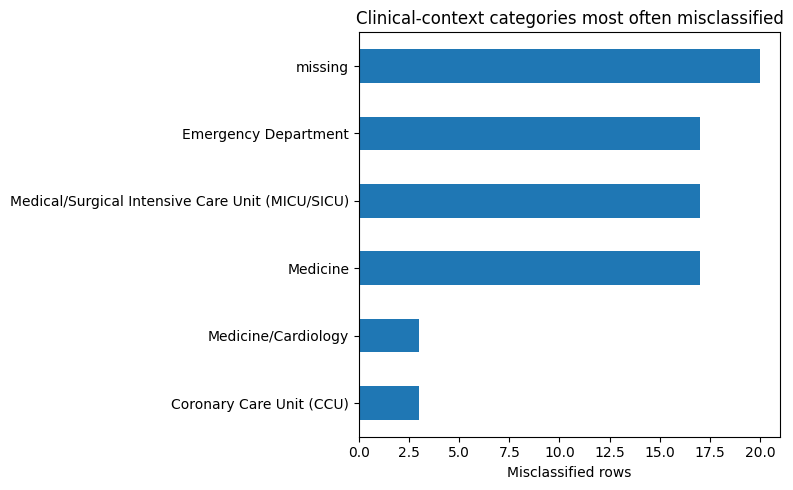

In [23]:
error_mask = hybrid_targets != hybrid_pred_labels
n_errors = int(error_mask.sum())
print(f"Misclassified test rows: {n_errors:,} / {len(hybrid_targets):,} ({n_errors / max(len(hybrid_targets),1):.2%})")

error_pairs = pd.DataFrame({
    "actual": [CLASS_NAMES[i] for i in hybrid_targets[error_mask]],
    "predicted": [CLASS_NAMES[i] for i in hybrid_pred_labels[error_mask]],
})
if len(error_pairs):
    print("Most common confusion pairs:")
    print(error_pairs.value_counts().head(12))
else:
    print("No multiclass errors found. Re-run the leakage audit before accepting a perfect result.")

# Clinical-context categories associated with multiclass mistakes.
test_diag_vals = test_df["_diag_node"].to_numpy()
err_context = pd.Series(test_diag_vals[error_mask]).value_counts().head(10)
plt.figure(figsize=(8, 5))
if len(err_context):
    err_context.sort_values().plot(kind="barh")
plt.title("Clinical-context categories most often misclassified")
plt.xlabel("Misclassified rows")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300)
plt.show()


### Computational Efficiency


In [24]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    model.to(DEVICE).eval()
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    xt_b, xd_b, xta_b, _ = next(iter(test_loader))
    xt_b = xt_b.to(DEVICE, non_blocking=True)
    xd_b = xd_b.to(DEVICE, non_blocking=True)
    xta_b = xta_b.to(DEVICE, non_blocking=True)
    use_amp = bool(CONFIG.get('use_amp', True)) and DEVICE.type == 'cuda'
    with torch.inference_mode():
        for _ in range(5):
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                model(xt_b, xd_b, xta_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(50):
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                model(xt_b, xd_b, xta_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = (time.perf_counter() - start) / 50
    efficiency[name] = {'device': str(DEVICE), 'mixed_precision': use_amp, 'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xt_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "device": "cuda:0",
    "mixed_precision": true,
    "total_params": 100611,
    "trainable_params": 100611,
    "avg_batch_inference_time_sec": 0.004594941559998915,
    "throughput_samples_per_sec": 27856.719901358272
  }
}
